# Spectral atmospheric flux operator

In [1]:
import pyarts
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker

## Initialize the operator

See [SpectralAtmosphericFlux](pyarts.recipe.rst#pyarts.recipe.SpectralAtmosphericFlux).

In [2]:
fop = pyarts.recipe.SpectralAtmosphericFlux(species=["H2O-161", "O2-66", "N2-44", "CO2-626", "O3-XFIT"],
                                            remove_lines_percentile={"H2O": 70})

## Get the atmosphere (optional)
The atmosphere is the full atmospheric field of ARTS as a dictionary,
which is likely more than you wish to change.  You may change only part
of the atmosphere by simply creating a dictionary that only contains the
fields that you want to change.

In [3]:
atm = fop.get_atmosphere()

## Get the profile flux for the given `atm`
Passing `atm` is optional, if not passed the operator will use the current atmosphere,
which is the atmosphere that was set with the last call to `__call__`, or the constructor
default if no call to `__call__` has been made.

In [4]:
kays = np.linspace(400, 2500, 10001)
flux, alts = fop(pyarts.arts.convert.kaycm2freq(kays), atm)

## Plots

Text(0.5, 1.0, 'Upgoing spectral irradiance')

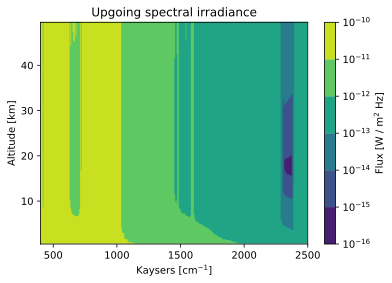

In [5]:
plt.figure(1, figsize=(6, 4))
plt.clf()
plt.gca().set_rasterization_zorder(0)
plt.contourf(kays, alts/1e3, flux.up.T, 50, locator=ticker.LogLocator(), zorder=-1)
plt.xlabel("Kaysers [cm$^{-1}$]")
plt.ylabel("Altitude [km]")
cm = plt.colorbar()
cm.set_label("Flux [W / m$^2$ Hz]")
plt.title("Upgoing spectral irradiance")

/tmp/ipykernel_95602/2854396954.py:4: UserWarning: Log scale: values of z <= 0 have been masked
  plt.contourf(kays, alts/1e3, flux.down.T, 50, locator=ticker.LogLocator(), zorder=-1)


Text(0.5, 1.0, 'Downgoing spectral irradiance')

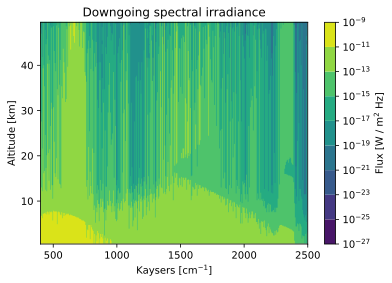

In [6]:
plt.figure(1, figsize=(6, 4))
plt.clf()
plt.gca().set_rasterization_zorder(0)
plt.contourf(kays, alts/1e3, flux.down.T, 50, locator=ticker.LogLocator(), zorder=-1)
plt.xlabel("Kaysers [cm$^{-1}$]")
plt.ylabel("Altitude [km]")
cm = plt.colorbar()
cm.set_label("Flux [W / m$^2$ Hz]")
plt.title("Downgoing spectral irradiance")